In [ ]:
import pandas as pd

In [ ]:
import random

In [ ]:
L = []
for i in range(10000):
  a = random.randint(1,6)
  b = random.randint(1,6)

  L.append(a + b)

In [ ]:
len(L)

10000

In [ ]:
L[:5]

[5, 6, 9, 10, 4]

In [ ]:
s = (pd.Series(L).value_counts()/pd.Series(L).value_counts().sum()).sort_index()

In [ ]:
import numpy as np
np.cumsum(s)

,count
2,0.0286
3,0.0845
4,0.1704
5,0.2801
6,0.4177
7,0.5867
8,0.7234
9,0.8309
10,0.9155
11,0.9717


<Axes: >

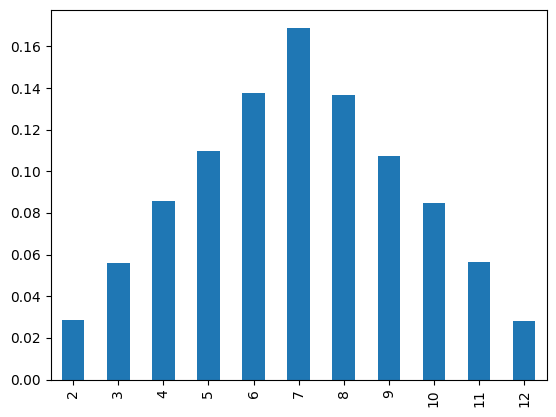

In [ ]:
s.plot(kind='bar')

<Axes: >

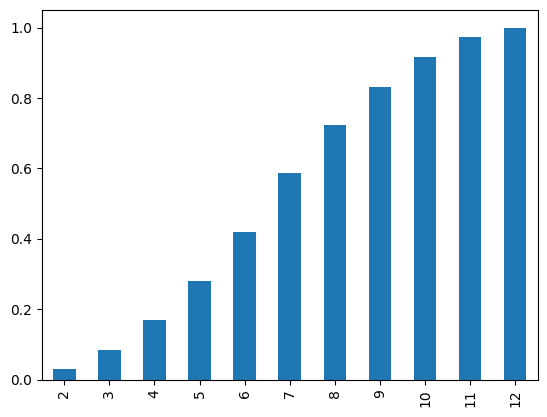

In [ ]:
np.cumsum(s).plot(kind='bar')

# Parametric Density Estimation

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import normal

sample = normal(loc=50, scale=5,size=1000)

In [ ]:
sample.mean()

np.float64(50.2574654597506)

(array([  2.,   8.,  41., 130., 206., 257., 204.,  93.,  41.,  18.]),
 array([33.14018031, 36.28285956, 39.42553881, 42.56821806, 45.71089731,
        48.85357655, 51.9962558 , 55.13893505, 58.2816143 , 61.42429354,
        64.56697279]),
 <BarContainer object of 10 artists>)

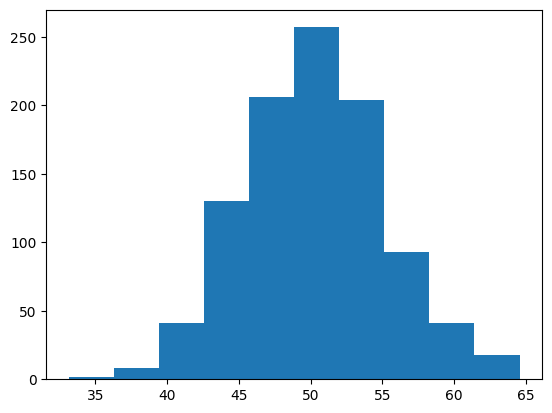

In [ ]:
# plot histogram to understand the distribution of data
plt.hist(sample,bins=10)

In [ ]:
# calculate sample mean and sample std dev
sample_mean = sample.mean()
sample_std = sample.std()

In [ ]:
# fit the distribution with the above parameters

from scipy.stats import norm
dist = norm(sample_mean, sample_std)

In [ ]:
values = np.linspace(sample.min(),sample.max(),100)

In [ ]:
sample.max()

np.float64(64.56697279155796)

In [ ]:
probabilities = [dist.pdf(value) for value in values]

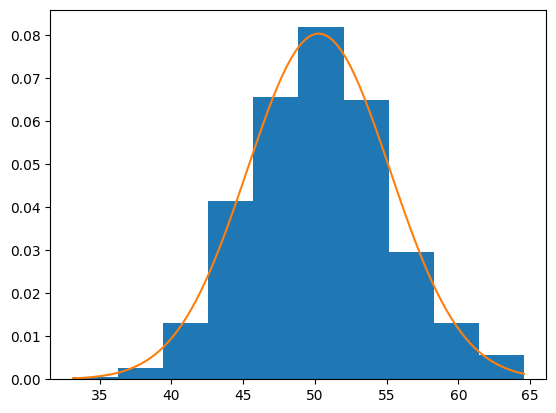

In [ ]:
# plot the histogram and pdf
plt.hist(sample,bins=10,density=True)
plt.plot(values,probabilities)

/tmp/ipython-input-1482356190.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sample)


<Axes: ylabel='Density'>

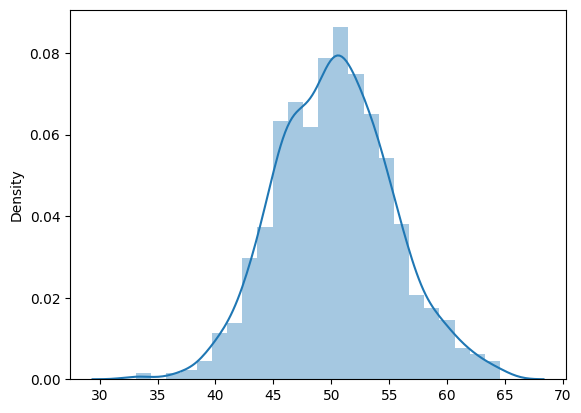

In [ ]:
import seaborn as sns
sns.distplot(sample)

# KDE

In [ ]:
# generate a sample
sample1 = normal(loc=20, scale=5, size=300)
sample2 = normal(loc=40, scale=5, size=700)
sample = np.hstack((sample1, sample2))

In [ ]:
sample

array([18.33192874, 21.28581269, 26.33485853, 15.29484167, 23.74599189,
       23.56298812, 21.90417596, 15.26253726, 17.42515422, 14.54676932,
       20.42449351, 24.41125525,  7.03370793, 14.83924115, 27.84092478,
       23.86186901, 27.62520286, 25.12665184, 23.1022945 , 21.7588068 ,
       21.97655953, 23.31277583, 17.79792515, 15.62871077, 19.41047645,
       19.5350729 , 16.97669193, 14.71405664, 22.4212965 , 17.03007862,
       18.42491439, 17.87214199, 18.54672486, 18.40953807, 28.44117235,
       23.67012608, 17.76831514, 23.87793716, 19.21238122, 19.31812839,
       18.54828648, 13.88274509, 24.07890921, 21.30309361, 23.11196038,
       27.29956228, 17.33149468, 27.17331389, 14.9587204 , 10.17045789,
       32.48738247, 23.1690274 , 21.93530663, 13.87028554, 28.75276822,
       16.47729212, 18.28218952, 19.00265805, 17.17742249, 23.33867352,
       17.18554839, 11.15754641, 16.02931642, 27.72875508, 13.08567435,
       15.43158716, 20.21677227, 21.15015596, 23.66558329, 12.25

(array([ 2.,  1.,  1.,  0.,  5.,  5.,  4.,  7., 12., 21., 17., 21., 17.,
        22., 15., 22., 29., 18., 22., 20., 11.,  8., 12.,  6., 12., 10.,
         9., 21., 22., 28., 32., 47., 46., 51., 59., 63., 55., 61., 37.,
        38., 30., 20., 23., 15., 10.,  5.,  5.,  1.,  1.,  1.]),
 array([ 5.48787527,  6.46592488,  7.44397449,  8.4220241 ,  9.40007371,
        10.37812332, 11.35617293, 12.33422254, 13.31227215, 14.29032176,
        15.26837137, 16.24642098, 17.22447059, 18.2025202 , 19.18056981,
        20.15861942, 21.13666903, 22.11471864, 23.09276825, 24.07081786,
        25.04886747, 26.02691708, 27.00496669, 27.9830163 , 28.96106591,
        29.93911552, 30.91716513, 31.89521474, 32.87326435, 33.85131396,
        34.82936357, 35.80741318, 36.78546279, 37.7635124 , 38.74156201,
        39.71961162, 40.69766123, 41.67571084, 42.65376045, 43.63181006,
        44.60985967, 45.58790928, 46.56595889, 47.5440085 , 48.52205811,
        49.50010772, 50.47815733, 51.45620694, 52.43425655,

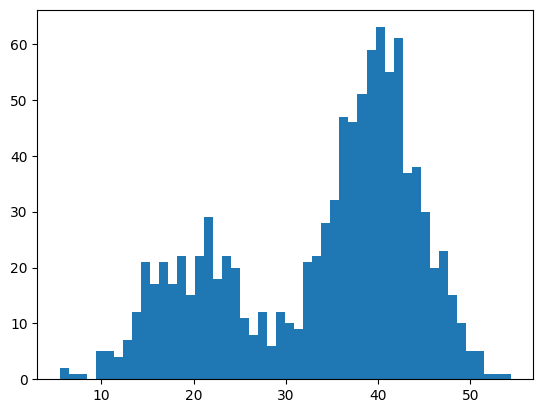

In [ ]:
# plot histogram bins=50
plt.hist(sample,bins=50)

In [ ]:
from sklearn.neighbors import KernelDensity

model = KernelDensity(bandwidth=5, kernel='gaussian')

# convert data to a 2D array
sample = sample.reshape((len(sample), 1))

model.fit(sample)

KernelDensity(bandwidth=5)

In [ ]:
values = np.linspace(sample.min(),sample.max(),100)
values = values.reshape((len(values), 1))

In [ ]:
probabilities = model.score_samples(values)
probabilities = np.exp(probabilities)

`score_samples(values)` returns the log-density estimate of the input samples values. This is because the `score_samples()` method of the KernelDensity class returns the logarithm of the probability density estimate rather than the actual probability density estimate.

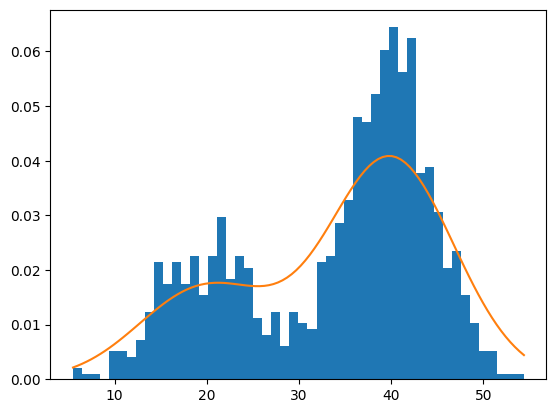

In [ ]:
plt.hist(sample, bins=50, density=True)
plt.plot(values[:], probabilities)
plt.show()

<Axes: ylabel='Density'>

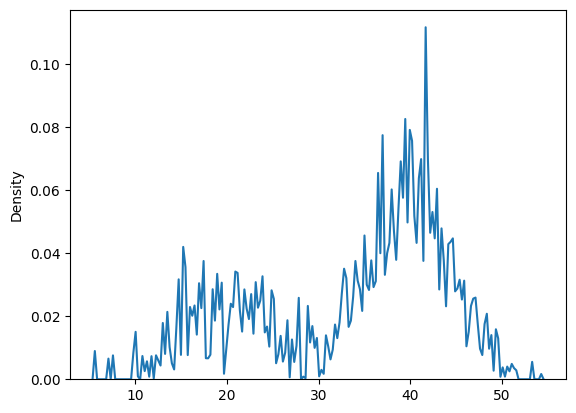

In [ ]:
sns.kdeplot(sample.reshape(1000),bw_adjust=0.02)

In [ ]:
import seaborn as sns

In [ ]:
df = sns.load_dataset('iris')

In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='Density'>

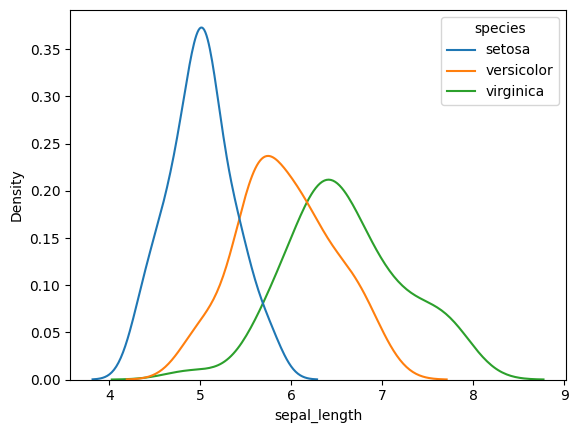

In [ ]:
sns.kdeplot(data=df,x='sepal_length',hue='species')

<Axes: xlabel='sepal_width', ylabel='Density'>

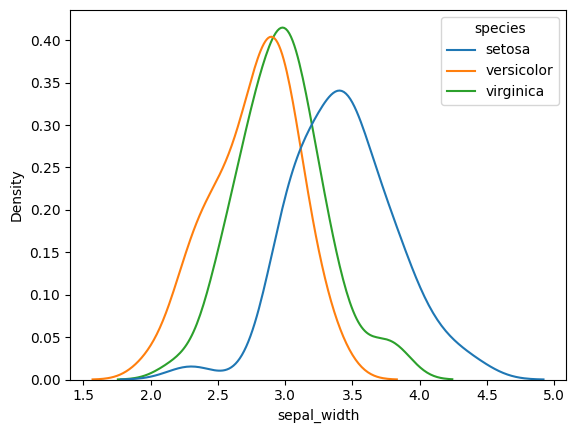

In [ ]:
sns.kdeplot(data=df,x='sepal_width',hue='species')

<Axes: xlabel='petal_length', ylabel='Density'>

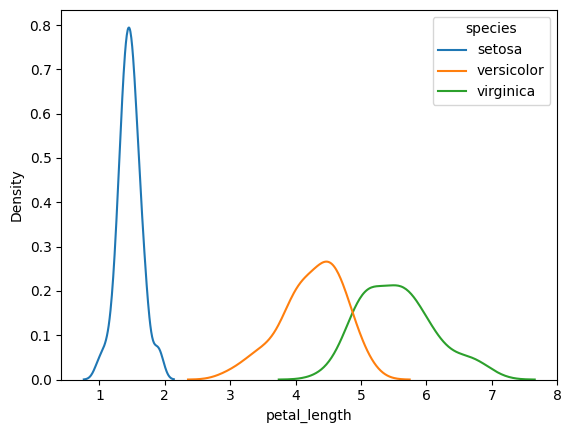

In [ ]:
sns.kdeplot(data=df,x='petal_length',hue='species')

<Axes: xlabel='petal_width', ylabel='Density'>

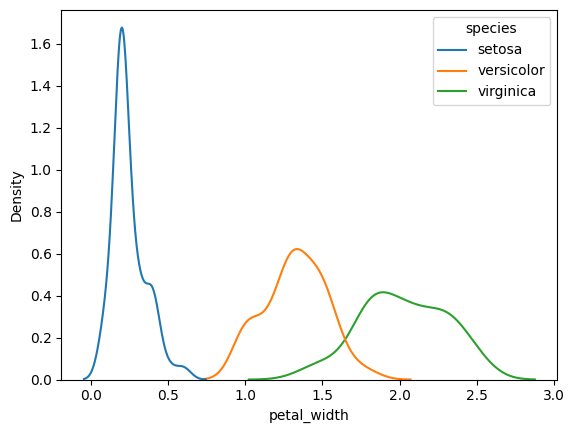

In [ ]:
sns.kdeplot(data=df,x='petal_width',hue='species')

In [ ]:
sns.kdeplot(df['petal_width'],hue=df['species'])
sns.ecdfplot(data=df,x='petal_width',hue='species')

ValueError: The following variable cannot be assigned with wide-form data: `hue`

In [ ]:
titanic = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

In [ ]:
titanic.head()

In [ ]:
# code here
sns.kdeplot(data=titanic,x='Age',hue='Sex')

In [ ]:
 sns.jointplot(data=df, x="petal_length", y="sepal_length", kind="kde",fill=True,cbar=True)

In [ ]:
sns.kdeplot(titanic['Age'])

In [ ]:
titanic['Age'].mean()

In [ ]:
x = (titanic['Age'] - titanic['Age'].mean())/titanic['Age'].std()

In [ ]:
sns.kdeplot(x)

In [ ]:
x.mean()

In [ ]:
x.std()

In [ ]:
titanic['Age'].skew()

In [ ]:
titanic['Age'].mean() + 3*titanic['Age'].std()

In [ ]:
titanic['Age'].mean() - 3*titanic['Age'].std()

In [ ]:
titanic[titanic['Age'] > 73]

In [ ]:
titanic['Age'].max()

In [4]:



import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

#CALULATION - uSING BUILTIN FUNCTION - eval

def evaluate(expr, A, B):
    return eval(expr, {"A": A, "B": B})

# TAKING INPUT FROM THE USER


print("Use operators: & (AND), | (OR), ^ (XOR), ~ (NOT)")
expr = input("Enter Boolean Expression using A and B: ")


# MAKING TRUTH TABLE


rows = []
for A in [0, 1]:
    for B in [0, 1]:
        F = int(evaluate(expr, A, B))
        rows.append([A, B, F])

df = pd.DataFrame(rows, columns=["A", "B", "F"])
print("\nTruth Table:\n")
print(df)



#VISUALIZATION


plt.figure(figsize=(4, 3))
sns.heatmap(df, annot=True, cmap="virdis", cbar=False, linewidths=1)
plt.title("Truth Table Heatmap")
plt.show()


#Note - As the python take ~ at bitwise operator not as logical not
#so we are using ~ as (1 - Variable) for the ouptput




Use operators: & (AND), | (OR), ^ (XOR), ~ (NOT)
Enter Boolean Expression using A and B: A^B

Truth Table:

   A  B  F
0  0  0  0
1  0  1  1
2  1  0  1
3  1  1  0


KeyError: "'virdis' is not a known colormap name"

<Figure size 400x300 with 0 Axes>